<a href="https://colab.research.google.com/github/Ailsasahda13/DataMining-Semester4/blob/main/Jobsheet8-Clustering/DatasetMahasiswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
# Load dataset

from google.colab import files
uploaded = files.upload()

Saving dataset_mahasiswa_fix.xlsx to dataset_mahasiswa_fix.xlsx


In [5]:
df_kelas = pd.read_excel('dataset_mahasiswa_fix.xlsx')
features = ['Usia', 'Pengeluaran BBM/Bulan', 'IPK', 'Tinggi (cm)', 'Berat (kg)']
X = df_kelas[features]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

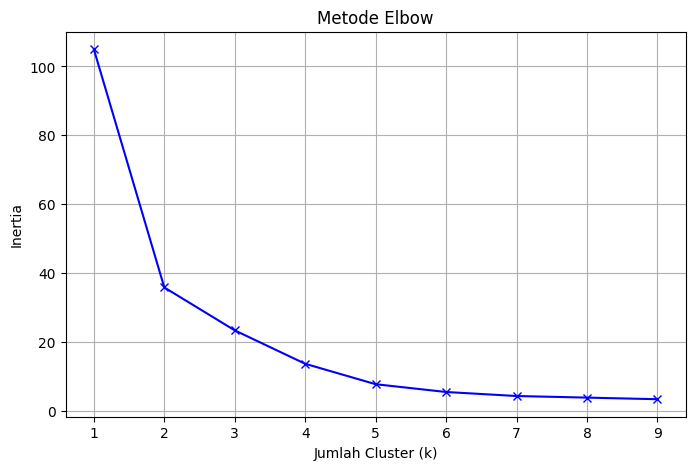

In [7]:
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow')
plt.grid(True)
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_kelas['Cluster'] = kmeans.fit_predict(X_scaled)

print(df_kelas.head())

            NIM                      Nama    Tempat, Tanggal Lahir  Usia  \
0  244107060159          Ahmad Rafi Hamdi       Blitar, 12-03-2005    20   
1  244107060084               Ahnaf Rifqi       Kediri, 05-07-2005    19   
2  244107060006       Ailsa Sahda Garizah  Tulungagung, 22-01-2005    20   
3  244107060035          Aiska Oca Amalia       Malang, 14-08-2005    19   
4  244107060057  Alyfa Zahra Qurrota Aini     Surabaya, 30-11-2005    19   

  Jenis Kelamin            Alamat         Kota Kendaraan  \
0             L   Jl. Melati No.1       Blitar     Motor   
1             L    Jl. Mawar No.2       Kediri     Motor   
2             P  Jl. Kenanga No.3  Tulungagung     Motor   
3             P   Jl. Dahlia No.4       Malang     Motor   
4             P  Jl. Anggrek No.5     Surabaya     Motor   

   Pengeluaran BBM/Bulan  IPK     Hobi  Tinggi (cm)  Berat (kg)  Cluster  
0                 200000  3.5   Futsal          170          65        2  
1                 180000  3.6   

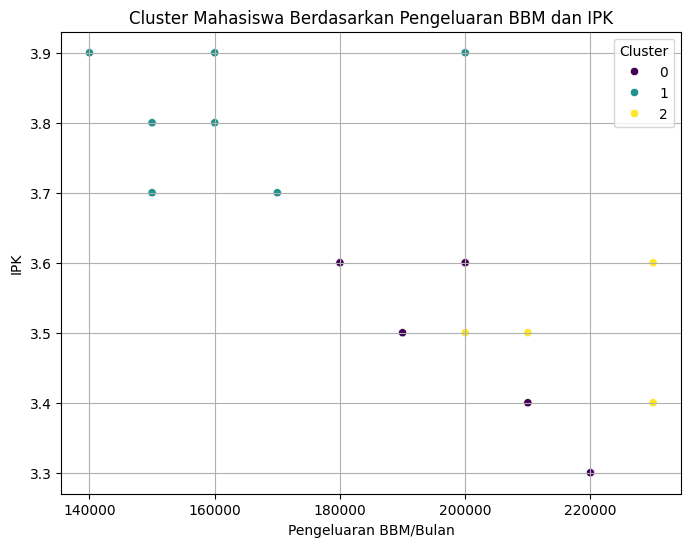

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_kelas['Pengeluaran BBM/Bulan'],
    y=df_kelas['IPK'],
    hue=df_kelas['Cluster'],
    palette='viridis'
)

plt.title('Cluster Mahasiswa Berdasarkan Pengeluaran BBM dan IPK')
plt.xlabel('Pengeluaran BBM/Bulan')
plt.ylabel('IPK')
plt.grid(True)
plt.show()

In [15]:
silhouette_avg = silhouette_score(X_scaled, df_kelas['Cluster'])
print("Silhouette Score:", silhouette_avg)

print("Inertia:", kmeans.inertia_)

Silhouette Score: 0.519474909531375
Inertia: 23.402413094705178


no 3


In [9]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
df_kelas['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

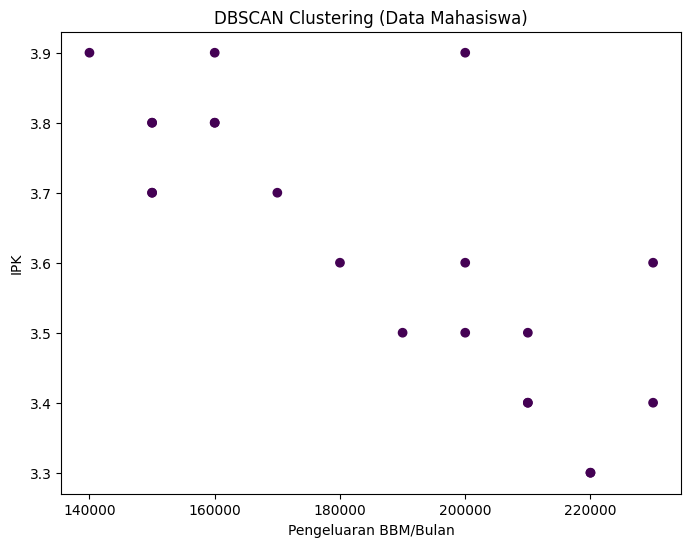

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_kelas['Pengeluaran BBM/Bulan'],
    df_kelas['IPK'],
    c=df_kelas['DBSCAN_Cluster'],
    cmap='viridis'
)

plt.title("DBSCAN Clustering (Data Mahasiswa)")
plt.xlabel("Pengeluaran BBM/Bulan")
plt.ylabel("IPK")
plt.show()

In [13]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
df_kelas['Hierarchical'] = agg.fit_predict(X_scaled)

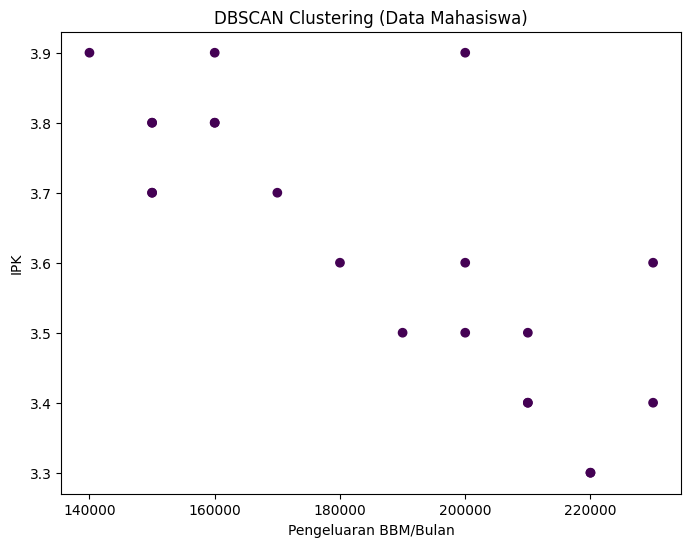

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(
    df_kelas['Pengeluaran BBM/Bulan'],
    df_kelas['IPK'],
    c=df_kelas['DBSCAN_Cluster'],
    cmap='viridis'
)

plt.title("DBSCAN Clustering (Data Mahasiswa)")
plt.xlabel("Pengeluaran BBM/Bulan")
plt.ylabel("IPK")
plt.show()